In [226]:
import numpy as np
import qiskit 
from qiskit.circuit import QuantumRegister, QuantumCircuit, Parameter
from qiskit.quantum_info import Pauli, SparsePauliOp
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
import random

import matplotlib.pyplot as plt

import pandas as pd

import scipy.optimize as opt

# Overview

$ A = I + 0.5X + 0.5Z $, so $ \langle A \rangle = 1 + 0.5 \langle X \rangle + 0.5 \langle Z \rangle $

So 2 different measurements are needed, Z and X

In [227]:
def ansatz():
    V = QuantumCircuit(1)

    param = Parameter('θ')

    V.h(0)
    V.ry(param, 0)

    return V, param

ansatz()[0].draw('mpl')

coeffs = [1, 0.5, 0.5]

In [228]:
I = np.array([
    [1, 0],
    [0, 1]
]) 

X = np.array([
    [0, 1],
    [1, 0]
])

Z = np.array([
    [1, 0],
    [0, -1]
]) 

paulis = [I, X, Z]

coeffs = [1, 0.5, 0.5]
A = sum(c * P for c, P in zip(coeffs, paulis))
b = np.array([[1/np.sqrt(2)], [1/np.sqrt(2)]])

# numerator and denominator of the cost function
N = np.conj(A.T) @ (b @ np.conj(b.T)) @ A
D = np.conj(A.T) @ A

print(f"A: \n {A}\n|b>: \n{b}\n\nSolution: \n{np.linalg.inv(A) @ b}")

Ni = [0.5 * np.trace(N @ P) for P in paulis]
Di = [0.5 * np.trace(D @ P) for P in paulis]

A: 
 [[1.5 0.5]
 [0.5 0.5]]
|b>: 
[[0.70710678]
 [0.70710678]]

Solution: 
[[1.11022302e-16]
 [1.41421356e+00]]


In [229]:
V, θ = ansatz()

def get_expvals(θ, l=None, lp=None, j=1):
    # extract the two needed expectation values from the circuit
    
    # first lets build the circuit

    vqls = QuantumCircuit(1)

    # variational form
    vqls.compose(V, inplace=True)
    vqls.barrier()

    # display(vqls.draw('mpl'))

    # measure the numerator observable
    observable = [[SparsePauliOp(["I", "X", "Z"], Ni)]]
    estimator = StatevectorEstimator()

    pub = (vqls, observable, [θ])
    job = estimator.run([pub])

    evs = job.result()[0].data.evs
    ev_n = evs[0][0]

    # measure the denominator observable (norm)
    observable = [[SparsePauliOp(["I", "X", "Z"], Di)]]
    estimator = StatevectorEstimator()

    pub = (vqls, observable, [θ])
    job = estimator.run([pub])

    evs = job.result()[0].data.evs
    ev_d = evs[0][0]

    return ev_n, ev_d

get_expvals(0.5)

(np.float64(1.7680134079372198), np.float64(1.8981570232861693))

In [230]:
def cost_function(θ):

    num, denom = get_expvals(θ)

    return 1 - (num/denom)

cost_function(2)


np.float64(0.12990488729689342)

[array(0.09998847),
 array(0.09998847),
 array(0.03304474),
 array(0.03304474),
 array(0.03304474),
 array(0.03304474),
 array(0.0147082),
 array(0.00108694),
 array(0.00108694),
 array(0.00108694),
 array(0.00108694),
 array(6.42655471e-05),
 array(6.42655471e-05),
 array(6.42655471e-05),
 array(4.77640733e-08),
 array(4.77640733e-08),
 array(4.77640733e-08),
 array(4.77640733e-08),
 array(4.57411886e-14),
 array(4.57411886e-14),
 array(4.57411886e-14),
 array(4.57411886e-14),
 array(4.57411886e-14),
 array(4.57411886e-14),
 array(4.57411886e-14)]

 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: 4.574118861455645e-14
       x: [ 1.571e+00]
     nit: 38
   maxcv: 0.0
    nfev: 24

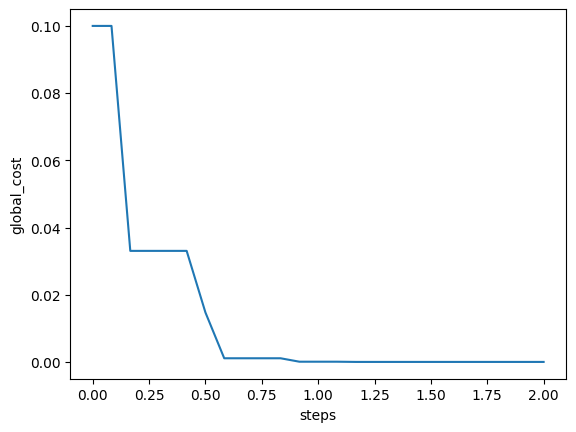

In [231]:
α = [0.001 * random.random()]

history = []
def log_step(xk):
    cost = cost_function(xk)
    history.append(np.copy(cost))

# history.append(np.copy())
log_step(α)

res = opt.minimize(cost_function, α, method="COBYQA", callback=log_step)

xs = np.linspace(0, 2, len(history))

plt.plot(xs, [h for h in history])
plt.xlabel("steps")
plt.ylabel("global_cost")
display(history)
res


In [232]:
opt_θ = res.x
opt_θ

# get norm to reconstruct statevector
_, ev_d = get_expvals(opt_θ)
norm_x = 1/ np.sqrt(ev_d)

variational_form = QuantumCircuit(1)
variational_form.compose(V, inplace=True)

bound = variational_form.assign_parameters(opt_θ)
variational_form.draw('mpl')

bound.measure_all()

n_shots = 10_000

sampler = StatevectorSampler()
job = sampler.run([bound], shots=n_shots)
result = job.result()[0]

counts = result.data.meas.get_counts()
probs = {k: v / n_shots for k, v in counts.items()}

statevector = np.zeros(2)
for bitstr, p in probs.items():
    idx = int(bitstr, 2)
    statevector[idx] = np.sqrt(p)

# statevector /= np.linalg.norm(statevector)
display(probs)
display(statevector * norm_x)

{'1': 1.0}

array([0.        , 1.41421296])